Score: 116.3133670816805

In [26]:
from contextlib import contextmanager
import time

@contextmanager
def timer(name):
    t0 = time.time()
    yield
    print(f"[{name}] done in {(time.time() - t0) * 1000:.1f} msec")

In [27]:
from pathlib import Path
import time
import numpy as np

In [28]:
def calc_mu_sigma(k, e, vs):
    mu = (k-vs)*e + vs*(1-e)
    sigma = k*e*(1-e)
    return mu, sigma

def is_out_of_range(y, x, N):
    return not ((0 <= x < N) and (0 <= y < N))

# Env

In [29]:
# --------------------  #
class Env:

    def __init__(self, file_path):
        with open(file_path, mode="r") as f:
            lines = f.readlines()
            N, M, ESP = lines[0].split()
            N, M, ESP = int(N), int(M), float(ESP)
            GRID = []
            lines = lines[1:]
            for _line in lines[:M]:
                _line = _line.split()
                ps = []
                for i in range(int(_line[0])):
                    ps.append((int(_line[2 * i + 1]), int(_line[2 * i + 2])))
                GRID.append(ps)
            lines = lines[2*M:]
            ANS_GRID = []
            for _line in lines[:N]:
                ANS_GRID.append(list(map(int, _line.split())))
        
        self.N = N
        self.M = M
        self.esp = ESP
        self.grids = GRID
        self.ans_grid = ANS_GRID
        
        self.total_oil_num = sum(len(g) for g in self.grids)
        self.score = 10 ** 9

        cnt = 0
        for y in range(N):
            for x in range(N):
                if self.ans_grid[y][x] > 0:
                    cnt += 1
        self.ans_point_size = cnt
    
        self._sum_oil = 0
        self._score = 0

        self.plus_coordinates = []
        self.queries1 = []
        self.queries2 = []
        self.fixed_board = [[None for _ in range(N)] for _ in range(N)]

    def is_ok(self):
        return self._sum_oil == self.total_oil_num
        
    def query1(self, coordinate):
        y, x = coordinate
        self._score += 1
        resp = self.ans_grid[y][x]
        self.queries1.append((coordinate, resp))
        self.fixed_board[y][x] = resp
        if resp > 0:
            self._sum_oil += resp
            self.plus_coordinates.append(coordinate)
        return resp

    def query2(self, coordinates):
        k = len(coordinates)
        vs = sum(self.ans_grid[y][x] for y, x in coordinates)
        mu, sigma = calc_mu_sigma(k, self.esp, vs)
        rng = np.random.default_rng()
        resp = max(0, round(rng.normal(mu, sigma)))
        self._score += 1 / np.sqrt(k)
        self.queries2.append(resp)
        return resp

    def answer(self, coordinates):
        is_ok = self.total_oil_num == sum(self.ans_grid[y][x] for y, x in coordinates)
        if is_ok:
            self.score = self._score
        else:
            self._score += 1
        return is_ok
    
    def answer_from_board(self, board):
        has_oils = []
        for y in range(self.N):
            for x in range(self.N):
                if board[y][x] > 0:
                    has_oils.append((y, x))
        return self.answer(has_oils)

    @property
    def query1_count(self):
        return len(self.queries1)

In [30]:
import random

class BoardSimulator:
    
    SIMULATE_NUM = 10 ** 8
    TIME_OUT = 1.5

    def __init__(self, env:Env):
        self.env:Env = env

        self.simulate_avg_num = 0
        self.simulate_cnt = 0

    def _search_placement_indexes(self):
        """ 現在の確定盤面に対して配置可能なインデックスを計算する"""

        N = self.env.N
        M = self.env.M
        f_board = self.env.fixed_board
        grids = self.env.grids

        placement_indexes = {}
        for m in range(M):
            now_grids = grids[m]
            now_placement_indexes = set()
            for y in range(N):
                for x in range(N):
                    flag = True
                    for coordinate in now_grids:
                        ny, nx = y + coordinate[0], x + coordinate[1]
                        if is_out_of_range(ny, nx, N):
                            flag = False
                            break
                        if f_board[ny][nx] is None:
                            continue
                        if f_board[ny][nx] == 0:
                            flag = False
                            break
                    if flag:
                        now_placement_indexes.add((y, x))
            placement_indexes[m] = list(now_placement_indexes)

        return placement_indexes
    
    def _calc_cost_from_simulated_board(self, simulated_board):

        N = self.env.N
        f_board = self.env.fixed_board

        cost = 0
        for y in range(N):
            for x in range(N):
                if f_board[y][x] is None:
                    continue
                v = abs(simulated_board[y][x] - f_board[y][x])
                cost += v
        return cost

    def _simulate_board(self):
        """
        現在の盤面と最も一致している（コストの低い）盤面で、最も正の数である確率が高い座標を返す。

        盤面のあるインデックスが正の数である確率
        現在の盤面との乖離コスト（シミュレート盤面のある値が、現在の値より大きければ加算）
        そのコストであったときの盤面の総数
        シミュレート可能総数
        """

        start_time = time.time()

        INF = 10**9

        N = self.env.N
        M = self.env.M
        f_board = self.env.fixed_board
        grids = self.env.grids

        min_cost = INF
        same_cost_cnt = 0
        plus_count_board = [[0 for _ in range(N)] for _ in range(N)]

        ans_board = None
        only_one_ans_board = False

        placement_indexes = self._search_placement_indexes()
        for simulate_num in range(BoardSimulator.SIMULATE_NUM):
            now_board = [[0 for _ in range(N)] for _ in range(N)]
            for m in range(M):
                sampling_index = random.choice(placement_indexes[m])
                for y, x in grids[m]:
                    ny, nx = y + sampling_index[0], x + sampling_index[1]
                    now_board[ny][nx] += 1
            cost = self._calc_cost_from_simulated_board(now_board)
            if cost == 0:
                if ans_board is None:
                    ans_board = now_board
                    only_one_ans_board = True
                else:
                    only_one_ans_board = False
            if cost < min_cost:
                min_cost = cost
                same_cost_cnt = 0
                plus_count_board = [[0 for _ in range(N)] for _ in range(N)]
            if cost <= min_cost:
                for y in range(N):
                    for x in range(N):
                        if now_board[y][x] > 0:
                            plus_count_board[y][x] += 1
                    same_cost_cnt += 1
            if time.time() - start_time > BoardSimulator.TIME_OUT / N ** 2:
                # シミュレート部分に合計3秒以上かけるとまずい
                break
        self.simulate_avg_num = 1 / (1+self.simulate_cnt) * (self.simulate_cnt + simulate_num)
        
        max_coordinate = None
        max_cnt = -1
        for y in range(N):
            for x in range(N):
                if f_board[y][x] is not None:
                    continue
                cnt = plus_count_board[y][x]
                if cnt > max_cnt:
                    max_cnt = cnt
                    max_coordinate = (y, x)
        
        if only_one_ans_board and (self.env.query1_count > (N**2 * 0.15)):
            return max_coordinate, ans_board
        else:
            return max_coordinate, None

    def get_next_coordinate(self):
        return self._simulate_board()

# Run

In [31]:
class Evaluator:

    def __init__(self):
        self.scores = []
        self.ans_points = []
        self.board_sizes = []

    def add_result(self, score, ans_point, board_size):
        self.scores.append(score)
        self.ans_points.append(ans_point)
        self.board_sizes.append(board_size)

In [32]:
def solve(env: Env):
    
    board_simulator = BoardSimulator(env)
    for i in range(500):
        if env.is_ok():
            env.answer(env.plus_coordinates)
            break
        coordinate, ans_board = board_simulator.get_next_coordinate()
        if ans_board is not None:
            if env.answer_from_board(ans_board):
                print("OK!!!!")
                break
            print("no")
        resp = env.query1(coordinate)
    print(board_simulator.simulate_avg_num)

In [33]:
import random

TEST_NUM = 100
evaluator = Evaluator()

def main():
    random.seed(0)
    for test_num in range(TEST_NUM):
        print(f"===== {test_num+1}/{TEST_NUM} =====")
        env = Env(file_path = Path(f"./in/{test_num:0>4}.txt"))
        solve(env)
        evaluator.add_result(env.score, env.ans_point_size, env.N**2)
        print(f"score:{env.score}")
main()

===== 1/100 =====
OK!!!!
537.0
score:89
===== 2/100 =====
no
no
OK!!!!
414.0
score:23
===== 3/100 =====
no
no
no
OK!!!!
915.0
score:51
===== 4/100 =====
no
OK!!!!
567.0
score:32
===== 5/100 =====
no
no
OK!!!!
880.0
score:51
===== 6/100 =====
no
no
no
OK!!!!
917.0
score:46
===== 7/100 =====
no
no
OK!!!!
166.0
score:100
===== 8/100 =====
no
no
no
no
no
no
no
no
no
no
no
OK!!!!
59.0
score:152
===== 9/100 =====
no
OK!!!!
744.0
score:59
===== 10/100 =====
OK!!!!
457.0
score:73
===== 11/100 =====
no
no
no
no
OK!!!!
687.0
score:78
===== 12/100 =====
OK!!!!
398.0
score:9
===== 13/100 =====
no
no
73.0
score:199
===== 14/100 =====
no
no
no
no
no
no
OK!!!!
145.0
score:132
===== 15/100 =====
no
no
no
no
no
no
no
no
no
OK!!!!
103.0
score:120
===== 16/100 =====
no
no
no
no
no
no
no
no
no
no
no
no
no
no
no
no
no
no
no
no
no
no
no
OK!!!!
143.0
score:101
===== 17/100 =====
no
no
no
no
no
no
89.0
score:170
===== 18/100 =====
no
OK!!!!
213.0
score:133
===== 19/100 =====
no
no
no
no
no
no
no
no
no
OK!!!!


# Evaluate

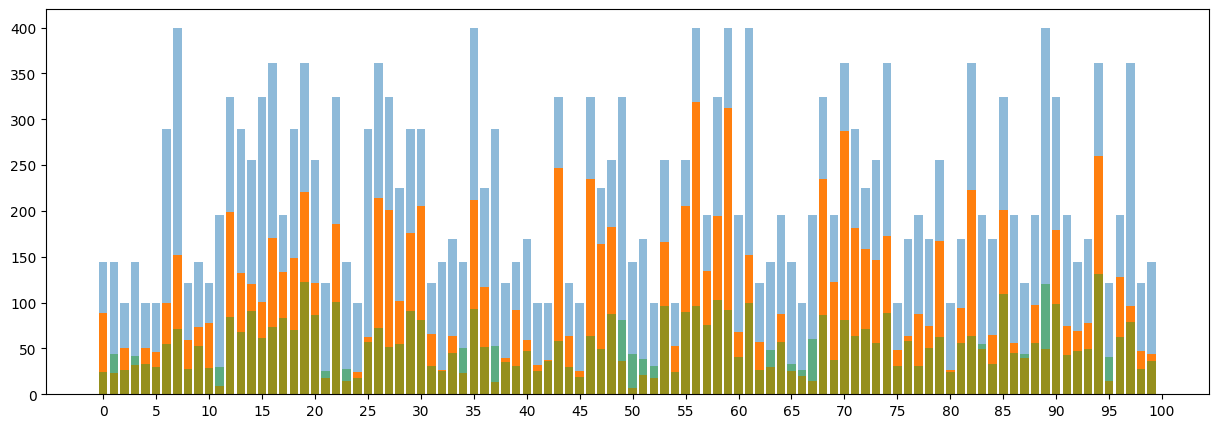

105.66


In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.bar(list(range(len(evaluator.board_sizes))), evaluator.board_sizes, alpha=0.5)
plt.bar(list(range(len(evaluator.scores))), evaluator.scores)
plt.bar(list(range(len(evaluator.ans_points))), evaluator.ans_points, alpha=0.5)

plt.xticks(range(0, len(evaluator.scores)+1, 5))
plt.show()

print(sum(evaluator.scores) / len(evaluator.scores))